In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

Raw data from 21-Sept-2026 to 05-Oct-2026

In [2]:
raw_data=pd.read_excel(r'C:\Users\Jose.Hurtado\Downloads\1JON.xlsx')
raw_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 15532 entries, 0 to 15531
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Created  15532 non-null  str  
 1   Message  15532 non-null  str  
 2   Status   15532 non-null  str  
dtypes: str(3)
memory usage: 364.2 KB


In [3]:
print(raw_data.iloc[raw_data.shape[0]-1])

Created                              2026-10-05 16:14:55.040
Message    [{"Protocol":"0x2626","MessageType":"LocationI...
Status     0x26260200532D990867284063945283001902581E0000...
Name: 15531, dtype: str


In [4]:
raw_data_codes=[]

for i in range(0,raw_data.shape[0]):
    raw_data_codes.append(raw_data.iloc[i,2][6:8])

raw_data['Codes']=raw_data_codes
raw_data['Codes'].value_counts()

Codes
02    10014
03     4195
09      818
04      444
01       50
11       11
Name: count, dtype: int64

In [5]:
torch_codes_02=raw_data[raw_data['Codes'].str.contains('02')]
torch_codes_04=raw_data[raw_data['Codes'].str.contains('04')]
torch_codes_0204=pd.concat([torch_codes_02,torch_codes_04])

torch_codes_0204.to_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\zonar\torch_analysis.csv',sep=',')

ignition_on_interval=[]
ignition_off_interval=[]
io=[]
odometer=[]
date=[]
ext_ps=[]
speed=[]
#over_speed=[]
gnss=[]
#a_code=[]
#direction=[]
accum_fuel_consumption=[]
#instant_fuel_consumption=[]
rpm=[]
cool_temp=[]
#air_in_flow_temp=[]
engine_load=[]
remain_fuel_rate=[]

for i in range(0,torch_codes_0204.shape[0]):
    ignition_on_interval.append(int(torch_codes_0204.iloc[i,2][32:36],16))
    ignition_off_interval.append(int(torch_codes_0204.iloc[i,2][36:40],16))
    io.append(bin(int(torch_codes_0204.iloc[i,2][64:68],16)))
    odometer.append(int(torch_codes_0204.iloc[i,2][72:80],16))
    date.append(torch_codes_0204.iloc[i,2][82:94])
    ext_ps.append((float(int(torch_codes_0204.iloc[i,2][126:130])))/100)
    speed.append(int(torch_codes_0204.iloc[i,2][131:133]))    
    #over_speed.append(torch_codes_0204.iloc[i,2])
    gnss.append(int(torch_codes_0204.iloc[i,2][51:52],16))
    #a_code.append(torch_codes_0204.iloc[])
    #direction.append(torch_codes_0204.iloc[i,2])
    accum_fuel_consumption.append(float(int(torch_codes_0204.iloc[i,2][134:142],16))/1000)
    #instant_fuel_consumption.append(torch_codes_0204.iloc[i,2]) invalid!
    rpm.append(int(torch_codes_0204.iloc[i,2][150:154],16))
    cool_temp.append(int(torch_codes_0204.iloc[i,2][158:160],16))
    #air_in_flow_temp.append(torch_codes_0204.iloc[i,2])
    engine_load.append(int(torch_codes_0204.iloc[i,2][162:164],16))
    remain_fuel_rate.append(torch_codes_0204.iloc[i,2][166:168])

torch_codes_0204['i_on']=ignition_on_interval
torch_codes_0204['i_off']=ignition_off_interval
torch_codes_0204['io']=io
torch_codes_0204['odometer']=odometer
torch_codes_0204['date']=date
torch_codes_0204['ext_ps']=ext_ps
torch_codes_0204['speed']=speed
torch_codes_0204['gnss']=gnss
torch_codes_0204['acc_fuel_c']=accum_fuel_consumption
torch_codes_0204['rpm']=rpm
torch_codes_0204['cool_temp']=cool_temp
torch_codes_0204['remain_fuel']=remain_fuel_rate
torch_codes_0204['engine_load']=engine_load

torch_codes_0204_ordered=torch_codes_0204.sort_values('date',ascending=True)

print(torch_codes_0204_ordered[['i_on','i_off','io','odometer','date','ext_ps','speed','acc_fuel_c','rpm','remain_fuel','gnss','cool_temp','engine_load']])

       i_on  i_off                 io  odometer          date  ext_ps  speed  \
0        25    600                0b0    164540  260921000409   12.75      0   
3        25    600                0b0    164540  260921001409   12.75      0   
6        25    600                0b0    164540  260921002409   12.75      0   
9        25    600                0b0    164540  260921003409   12.74      0   
12       25    600                0b0    164540  260921004409   12.75      0   
...     ...    ...                ...       ...           ...     ...    ...   
15526    25    600  0b100000000000000   1405781  261005161322   13.99     13   
15527    25    600  0b100000000000000   1405815  261005161327   13.99     24   
15528    25    600  0b100000000000000   1406028  261005161354   13.98     18   
15530    25    600  0b100000000000000   1406169  261005161421   13.92     31   
15531    25    600  0b100000000000000   1406265  261005161448   12.98      0   

       acc_fuel_c   rpm remain_fuel  gn

In [6]:
torch_codes_0204_ordered.info()

<class 'pandas.DataFrame'>
Index: 10458 entries, 0 to 15531
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Created      10458 non-null  str    
 1   Message      10458 non-null  str    
 2   Status       10458 non-null  str    
 3   Codes        10458 non-null  str    
 4   i_on         10458 non-null  int64  
 5   i_off        10458 non-null  int64  
 6   io           10458 non-null  str    
 7   odometer     10458 non-null  int64  
 8   date         10458 non-null  str    
 9   ext_ps       10458 non-null  float64
 10  speed        10458 non-null  int64  
 11  gnss         10458 non-null  int64  
 12  acc_fuel_c   10458 non-null  float64
 13  rpm          10458 non-null  int64  
 14  cool_temp    10458 non-null  int64  
 15  remain_fuel  10458 non-null  str    
 16  engine_load  10458 non-null  int64  
dtypes: float64(2), int64(8), str(7)
memory usage: 1.4 MB


In [7]:
df=torch_codes_0204_ordered[['i_on','i_off','io','odometer','date','ext_ps','speed','acc_fuel_c','rpm','remain_fuel','gnss','cool_temp','Status','engine_load']]
df.info()

<class 'pandas.DataFrame'>
Index: 10458 entries, 0 to 15531
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   i_on         10458 non-null  int64  
 1   i_off        10458 non-null  int64  
 2   io           10458 non-null  str    
 3   odometer     10458 non-null  int64  
 4   date         10458 non-null  str    
 5   ext_ps       10458 non-null  float64
 6   speed        10458 non-null  int64  
 7   acc_fuel_c   10458 non-null  float64
 8   rpm          10458 non-null  int64  
 9   remain_fuel  10458 non-null  str    
 10  gnss         10458 non-null  int64  
 11  cool_temp    10458 non-null  int64  
 12  Status       10458 non-null  str    
 13  engine_load  10458 non-null  int64  
dtypes: float64(2), int64(8), str(4)
memory usage: 1.2 MB


Odometer

164540
164540
164540
164540
164540
164540
164540
164540
164540
164540
164540
164540
164540
164540
164540
164540
164540
164540
164540
164540
164540
164540
164540
164540
164540
164540
164540
164540
164540
164540
164540
164540
164540
164540
164540
164540
164540
164540
164540
164540
164540
164540
164540
164540
164540
164540
164540
164540
164540
164540
164540
164540
164540
164540
164540
164540
164540
164540
164540
164540
164540
164540
164540
164540
164540
164540
164540
164540
164540
164540
164540
164540
164540
164540
164540
164540
164540
164540
164540
164540
164540
164540
164540
164540
164540
164540
164540
164540
164540
164540
164540
164540
164540
164540
164540
164540
164540
164540
164540
164540
164540
164540
164540
164540
164540
164540
164540
164540
164540
164540
164540
164540
164540
164540
164582
164582
164680
164680
164756
164756
164771
164771
164834
164834
165116
165116
165332
165332
165481
165481
165502
165502
165848
165848
166018
166018
166135
166135
166304
166304
166485
166485
166713

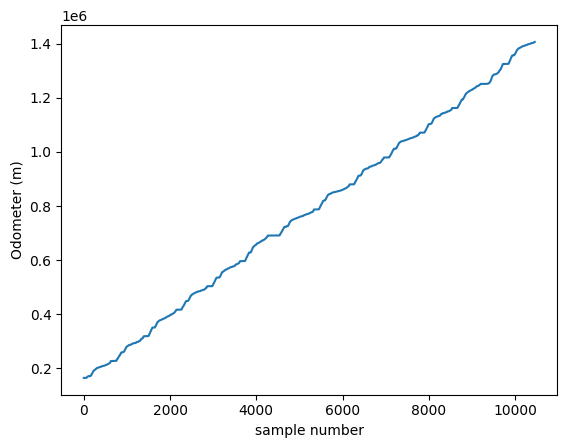

In [8]:
odometer=pd.DataFrame()
odometer_data=[]
x_axis=[]
date=[]
status=[]
#torch_codes_0204.info()

for i in range(0,df.shape[0]):
    print(int(df.iloc[i,3]))
    #if int(df.iloc[i,3]>80000000):
    print(int(df.iloc[i,3]))
    status.append(df.iloc[i,12])
    odometer_data.append(int(df.iloc[i,3]))
    date.append(df.iloc[i,4])
    x_axis.append(i)
try:
    print(max(odometer_data),min(odometer_data))
except:
    print(df.iloc[i,3])

odometer['sample_number']=x_axis
odometer['odometer']=odometer_data
odometer['date']=date
odometer['status']=status

plt.ylabel("Odometer (m)")
plt.xlabel('sample number')
#plt.xticks(range(0,5572,100),rotation=90)
plt.plot(x_axis,odometer_data)

#odometer.to_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\zonar\odometer.csv')

Speed

85 0


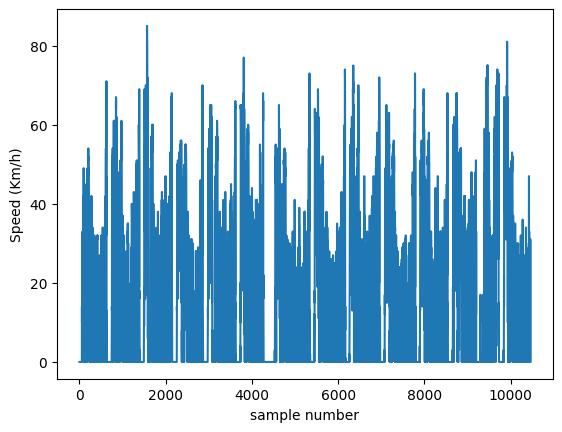

In [9]:
speed=pd.DataFrame()
speed_data=[]
x_axis=[]
date=[]
status=[]
#torch_codes_0204.info()

for i in range(0,df.shape[0]):                        
        status.append(df.iloc[i,12])
        speed_data.append(int(df.iloc[i,6]))
        date.append(df.iloc[i,4])
        x_axis.append(i)            

print(max(speed_data),min(speed_data))
speed['sample_number']=x_axis
speed['speed']=speed_data
speed['status']=status

plt.ylabel("Speed (Km/h)")
plt.xlabel('sample number')
plt.plot(x_axis,speed_data)

#speed.to_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\zonar\speed.csv')

RPM

2539 0


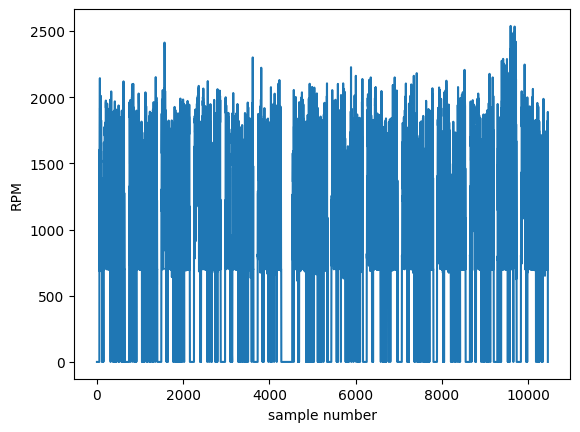

In [10]:
rpm=pd.DataFrame()
rpm_data=[]
x_axis=[]
date=[]
status=[]
#torch_codes_0204.info()

for i in range(0,df.shape[0]):
        if df.iloc[i,8]<65535:
                status.append(df.iloc[i,12])
                rpm_data.append(int(df.iloc[i,8]))
                date.append(df.iloc[i,4])
                x_axis.append(i)            

print(max(rpm_data),min(rpm_data))
rpm['sample_number']=x_axis
rpm['rpm']=rpm_data
rpm['status']=status

plt.ylabel("RPM")
plt.xlabel('sample number')
plt.plot(x_axis,rpm_data)
#rpm.to_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\zonar\rpm.csv')

Fuel

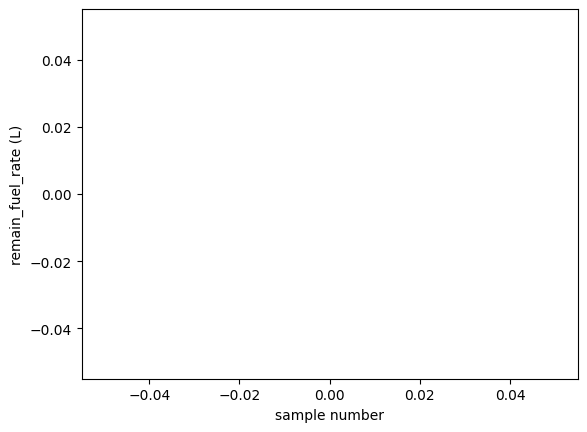

In [11]:
rfl=pd.DataFrame()
fuel_data=[]
x_axis=[]
date=[]
status=[]
status_aux=[]
#torch_codes_0204.info()

for i in range(0,df.shape[0]):
    if df.iloc[i,9]!='FF':               
        aux_data=df.iloc[i,12]
        if (len(aux_data)<170):
            status.append(df.iloc[i,12])
            x_axis.append(i) 
            fuel_data.append((int(df.iloc[i,9],16) & 127))
            date.append(df.iloc[i,4])

plt.plot(x_axis,fuel_data)
plt.ylabel("remain_fuel_rate (L)")
plt.xlabel('sample number')

rfl['fuel_data']=fuel_data
rfl['date']=date
rfl['raw_data']=status
#rfl.to_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\zonar\rfl_1i1v.csv',sep=',')

Cooling fluid Temperature 

86 0


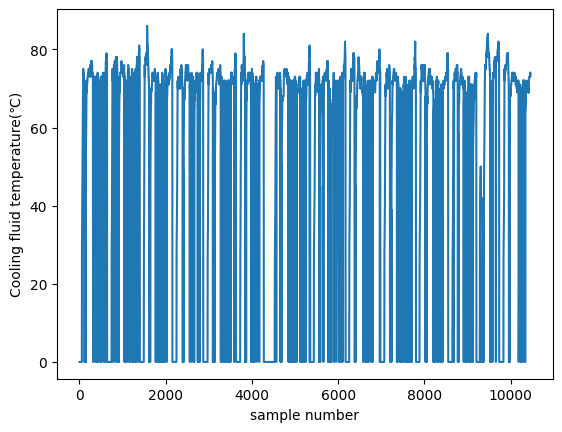

In [12]:
temp=pd.DataFrame()
temp_data=[]
x_axis=[]
date=[]
status=[]
#torch_codes_0204.info()

for i in range(0,df.shape[0]):
    if df.iloc[i,11]!=255:               
        aux_data=df.iloc[i,11]
        status.append(df.iloc[i,12])
        temp_data.append(df.iloc[i,11]-40)
        x_axis.append(i)         
        date.append(df.iloc[i,4])

print(max(temp_data),min(temp_data))
temp['sample_number']=x_axis
temp['date']=date
temp['temp']=temp_data
temp['status']=status

plt.ylabel("Cooling fluid temperature(℃)")
plt.xlabel('sample number')
plt.plot(x_axis,temp_data)

#temp.to_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\zonar\temp.csv')

Engine load

86 0


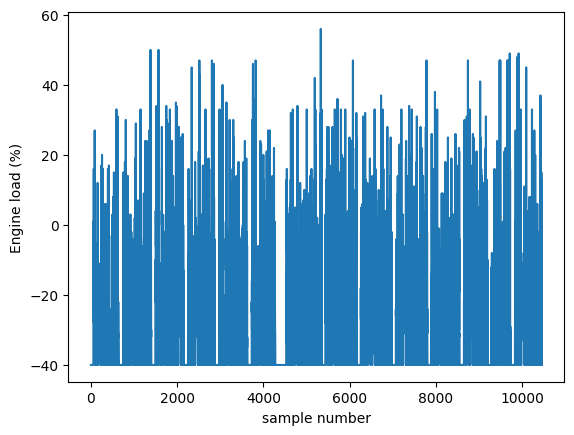

In [13]:
engine_load=pd.DataFrame()
engine_data=[]
x_axis=[]
date=[]
status=[]
#torch_codes_0204.info()

for i in range(0,df.shape[0]):
    if df.iloc[i,13]!=255:               
        aux_data=df.iloc[i,13]
        status.append(df.iloc[i,12])
        engine_data.append(df.iloc[i,13]-40)
        x_axis.append(i)         
        date.append(df.iloc[i,4])

print(max(temp_data),min(temp_data))
engine_load['sample_number']=x_axis
engine_load['date']=date
engine_load['engine load %']=engine_data
engine_load['status']=status

plt.ylabel("Engine load (%)")
plt.xlabel('sample number')
plt.plot(x_axis,engine_data)

#temp.to_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\zonar\engine.csv')